In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Tree Species Dataset.csv")
df.columns = df.columns.str.strip()
df.columns

Index(['Common Name', 'Category', 'Botanical Name', 'Land Type',
       'Land Type Width (m)', 'Water Requirement', 'Sunlight Requirement',
       'Climate', 'Soil Type', 'Carbon Sequestration (CO2/year)',
       'Pollution Filtration', 'Maintenance', 'Height (m)', 'Fruit', 'Flower'],
      dtype='object')

In [3]:
df

,Common Name,Category,Botanical Name,Land Type,Land Type Width (m),Water Requirement,Sunlight Requirement,Climate,Soil Type,Carbon Sequestration (CO2/year),Pollution Filtration,Maintenance,Height (m),Fruit,Flower
0,Checkered Hibiscus,Shrub,Hibiscus radiatus,"Home Gardens, Public Parks",0.5 - 1.5,Moderate Water,Full Sun,"Tropical, Sub-Tropical",Loamy Soils,1.5,2.55,Moderate,2.0,NaN,Yes
1,Jungle Geranium,Shrub,Ixora coccinea,"Medians & Dividers, Home Gardens",0.5 - 1.0,Moderate Water,"Full Sun, Semi-Shade","Tropical, Sub-Tropical",Loamy Soils,1.0,2.40,Moderate,1.5,Edible,Yes
2,Bougainvillea,Shrub,Bougainvillea glabra,"Medians & Dividers, Home Gardens, Mall & Shopp...",2.0 - 3.0,"Little Water, Moderate Water",Full Sun,Tropical,"Sandy Soils, Loamy Soils",4.0,3.10,Low,4.0,Not Edible,Yes
3,Oleander,Shrub,Nerium oleander,"Medians & Dividers, Industrial Green Belts",2.0 - 4.0,Moderate Water,Full Sun,"Tropical, Sub-Tropical","Sandy Soils, Loamy Soils",2.5,2.60,Low,6.0,Not Edible,Yes
4,Egyptian star-cluster,Shrub,Pentas lanceolata,"Home Gardens, Botanical Gardens",0.5 - 1.0,Moderate Water,"Full Sun, Semi-Shade",Tropical,Loamy Soils,0.8,2.45,Moderate,0.5,NaN,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Dwarf black plum,Small Tree,Syzygium cumini,"Home Gardens, Community Gardens",3.0 - 4.0,Moderate Water,Semi-Shade,"Tropical, Sub-Tropical",Loamy Soils,10.0,2.40,Moderate,5.0,Edible,Yes
194,Ceylon Ironwood,Medium Tree,Mesua ferrea,"Urban Forest, Public Parks",7.0 - 10.0,Moderate Water,Full Sun,"Tropical, Sub-Tropical","Loamy Soils, Clayey Soils",12.0,4.30,Moderate,15.0,Not Edible,Yes
195,Acacia Tree,Medium Tree,Acacia spp.,"Industrial Green Belts, Avenue Plantation",8.0 - 12.0,Moderate Water,Full Sun,Tropical,"Loamy Soils, Sandy Soils, Clayey Soils",15.0,3.15,Moderate,12.0,Edible,Yes
196,Horsetail Tree,Large Tree,Casuarina equisetifolia,"Riparian Buffer, Public Parks",12.0 - 20.0,Moderate Water,Full Sun,"Tropical, Sub-Tropical",Loamy Soils,20.0,2.50,Moderate,10.0,Not Edible,Yes


In [4]:
import geopandas as gpd

In [5]:
gdf = gpd.read_file("Community Park Area.geojson")
gdf.columns

Index(['id', 'Width', 'Area', 'Land Type', 'Soil Type', 'Climate', 'Latitude',
       'Longitude', 'Powerline', 'Category', 'geometry'],
      dtype='object')

In [6]:
gdf

,id,Width,Area,Land Type,Soil Type,Climate,Latitude,Longitude,Powerline,Category,geometry
0,1,3.0,219.1,Community Park,Loamy Soils,Tropical,80.227,12.972,No,Shrub,"MULTIPOLYGON (((416123.742 1434175.294, 416124..."
1,2,3.0,51.4,Community Park,Loamy Soils,Tropical,80.227,12.972,No,Shrub,"MULTIPOLYGON (((416125.808 1434175.803, 416142..."
2,3,3.0,138.8,Community Park,Loamy Soils,Tropical,80.227,12.972,No,Shrub,"MULTIPOLYGON (((416146.211 1434176.267, 416145..."
3,4,3.0,78.7,Community Park,Loamy Soils,Tropical,80.227,12.972,No,Shrub,"MULTIPOLYGON (((416128.556 1434143.545, 416128..."


In [7]:
l_gdf = gpd.read_file("Community Park lines.geojson")
l_gdf.columns

Index(['id', 'layer', 'path', 'geometry'], dtype='object')

In [8]:
l_gdf

,id,layer,path,geometry
0,2,1,MultiLineString?crs=EPSG:3857&field=id:integer...,"MULTILINESTRING ((416146.074 1434177.712, 4161..."
1,3,1,MultiLineString?crs=EPSG:3857&field=id:integer...,"MULTILINESTRING ((416126.031 1434174.411, 4161..."
2,4,2,MultiLineString?crs=EPSG:3857&field=id:integer...,"MULTILINESTRING ((416128.705 1434141.709, 4161..."
3,1,2,MultiLineString?crs=EPSG:3857&field=id:integer...,"MULTILINESTRING ((416123.95 1434173.85, 416105..."


In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely import wkt

# Global variable for storing recommendations
ALL_RECOMMENDATIONS = pd.DataFrame()

def load_tree_data(filepath):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    # Handle land type and width
    df['Land Type'] = df['Land Type'].str.split(', ')
    df[['Min Width (m)', 'Max Width (m)']] = df['Land Type Width (m)'].str.split(' - ', expand=True).astype(float)
    df['Climate'] = df['Climate'].str.split(', ')
    df['Soil Type'] = df['Soil Type'].str.split(', ')

    # Handle numeric columns
    df['Carbon Sequestration (CO2/year)'] = pd.to_numeric(df['Carbon Sequestration (CO2/year)'], errors='coerce')
    df['Pollution Filtration'] = pd.to_numeric(df['Pollution Filtration'], errors='coerce')

    # Clean maintenance column
    if 'Maintenance' in df.columns:
        df['Maintenance'] = df['Maintenance'].str.strip()

    # Remove duplicates
    df = df.drop_duplicates(subset=['Botanical Name'])

    return df

def load_area_data(filepath):
    gdf = gpd.read_file(filepath)

    # Ensure consistent column names
    gdf.columns = gdf.columns.str.strip()

    # Handle powerline column if it exists
    if 'Powerline' not in gdf.columns:
        gdf['Powerline'] = 'No'
    else:
        gdf['Powerline'] = gdf['Powerline'].str.strip().str.capitalize()

    # Convert geometry if needed
    if isinstance(gdf.geometry.iloc[0], str):
        gdf['geometry'] = gdf['geometry'].apply(wkt.loads)
        gdf = gpd.GeoDataFrame(gdf, geometry='geometry')

    # Ensure ID column exists
    if 'id' not in gdf.columns:
        gdf['id'] = range(1, len(gdf) + 1)

    return gdf

class TreeRecommender:
    def __init__(self, tree_df):
        self.tree_df = self._preprocess_tree_data(tree_df)
        self.model = self._build_model()
        self.X_train, self.X_test, self.y_train, self.y_test = None, None, None, None
        self._train_model()
        self._evaluate_model()
        self._plot_performance()

    def _preprocess_tree_data(self, df):
        df = df.explode('Land Type')
        df = df.explode('Climate')
        df = df.explode('Soil Type')

        # Create category indicators
        df['Is_Shrub'] = (df['Category'] == 'Shrub').astype(int)
        df['Is_Small_Tree'] = (df['Category'] == 'Small Tree').astype(int)
        df['Is_Medium_Tree'] = (df['Category'] == 'Medium Tree').astype(int)
        df['Is_Large_Tree'] = (df['Category'] == 'Large Tree').astype(int)

        # Handle fruit/flower columns
        df['Has_Fruit'] = (~df['Fruit'].isin(['N/A', 'No', np.nan])).astype(int)
        df['Has_Flowers'] = (df['Flower'] == 'yes').astype(int)

        # Clean water and sunlight requirements
        df['Water Requirement'] = df['Water Requirement'].str.strip()
        df['Sunlight Requirement'] = df['Sunlight Requirement'].str.strip()

        return df

    def _build_model(self):
        numeric_features = ['Min Width (m)', 'Max Width (m)', 'Carbon Sequestration (CO2/year)', 'Pollution Filtration']
        numeric_transformer = Pipeline(steps=[
            ('scaler', StandardScaler())
        ])

        categorical_features = ['Water Requirement', 'Sunlight Requirement', 'Climate', 'Soil Type']
        categorical_transformer = Pipeline(steps=[
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ])

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_features),
                ('cat', categorical_transformer, categorical_features)
            ])

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', RandomForestRegressor(
                n_estimators=100,
                max_depth=8,
                min_samples_split=5,
                random_state=42,
                n_jobs=-1
            ))
        ])

        return pipeline

    def _calculate_suitability_score(self):
        # Size score - smaller trees generally better for urban areas
        size_score = np.where(
            self.tree_df['Category'] == 'Shrub', 1.0,
            np.where(
                self.tree_df['Category'] == 'Small Tree', 0.9,
                np.where(
                    self.tree_df['Category'] == 'Medium Tree', 0.7,
                    0.5  # Large trees
                )
            )
        )

        # Maintenance score - lower maintenance is better
        maintenance_score = np.where(
            self.tree_df['Maintenance'] == 'Low', 1.0,
            np.where(
                self.tree_df['Maintenance'] == 'Moderate', 0.7,
                0.4  # High maintenance
            )
        )

        # Flower score - flowers add aesthetic value
        flower_score = self.tree_df['Has_Flowers'] * 0.5 + 0.5  # 0.5-1.0 range

        # Fruit score - edible fruit adds value
        fruit_score = np.where(
            self.tree_df['Fruit'] == 'Edible', 1.0,
            np.where(
                self.tree_df['Has_Fruit'], 0.7,
                0.5  # No fruit
            )
        )

        # Calculate composite score
        self.tree_df['Score'] = (
            0.30 * (self.tree_df['Carbon Sequestration (CO2/year)'] / self.tree_df['Carbon Sequestration (CO2/year)'].max()) +
            0.25 * (self.tree_df['Pollution Filtration'] / self.tree_df['Pollution Filtration'].max()) +
            0.15 * size_score +
            0.10 * maintenance_score +
            0.10 * flower_score +
            0.10 * fruit_score
        )

    def _train_model(self):
        self._calculate_suitability_score()

        features = self.tree_df[[
            'Min Width (m)', 'Max Width (m)', 'Carbon Sequestration (CO2/year)',
            'Pollution Filtration', 'Water Requirement',
            'Sunlight Requirement', 'Climate', 'Soil Type'
        ]]

        # Split data into training and test sets
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            features,
            self.tree_df['Score'],
            test_size=0.2,
            random_state=42
        )

        # Train the model
        self.model.fit(self.X_train, self.y_train)

    def _evaluate_model(self):
        # Make predictions
        train_pred = self.model.predict(self.X_train)
        test_pred = self.model.predict(self.X_test)

        # Calculate metrics
        self.metrics = {
            'Training R²': r2_score(self.y_train, train_pred),
            'Training MSE': mean_squared_error(self.y_train, train_pred),
            'Test R²': r2_score(self.y_test, test_pred),
            'Test MSE': mean_squared_error(self.y_test, test_pred),
            'Cross-Val R² (mean)': cross_val_score(
                self.model, self.X_train, self.y_train, cv=5, scoring='r2'
            ).mean(),
            'Cross-Val R² (std)': cross_val_score(
                self.model, self.X_train, self.y_train, cv=5, scoring='r2'
            ).std()
        }

        # Get feature importances
        rf_model = self.model.named_steps['regressor']
        self.feature_importances = pd.DataFrame({
            'feature': self._get_feature_names(),
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False)

    def _get_feature_names(self):
        """Get feature names after preprocessing"""
        preprocessor = self.model.named_steps['preprocessor']
        num_features = preprocessor.transformers_[0][2]
        cat_features = preprocessor.transformers_[1][1]\
                      .named_steps['onehot'].get_feature_names_out(
                          preprocessor.transformers_[1][2]
                      )
        return np.concatenate([num_features, cat_features])

    def _plot_performance(self):
        """Generate performance visualizations"""
        plt.figure(figsize=(15, 5))

        # Plot actual vs predicted for test set
        plt.subplot(1, 2, 1)
        test_pred = self.model.predict(self.X_test)
        sns.scatterplot(x=self.y_test, y=test_pred)
        plt.plot([self.y_test.min(), self.y_test.max()],
                [self.y_test.min(), self.y_test.max()], 'k--')
        plt.xlabel('Actual Scores')
        plt.ylabel('Predicted Scores')
        plt.title('Actual vs Predicted Suitability Scores')

        # Plot feature importance
        plt.subplot(1, 2, 2)
        top_features = self.feature_importances.head(10)
        sns.barplot(x='importance', y='feature', data=top_features)
        plt.title('Top 10 Feature Importances')
        plt.tight_layout()

        plt.savefig('model_performance.png')
        plt.close()

    def display_performance(self):
        """Print performance metrics and show feature importance"""
        print("\n=== Model Performance Evaluation ===")
        print(f"\nTraining R²: {self.metrics['Training R²']:.3f}")
        print(f"Training MSE: {self.metrics['Training MSE']:.3f}")
        print(f"\nTest R²: {self.metrics['Test R²']:.3f}")
        print(f"Test MSE: {self.metrics['Test MSE']:.3f}")
        print(f"\nCross-Validation R²: {self.metrics['Cross-Val R² (mean)']:.3f} (±{self.metrics['Cross-Val R² (std)']:.3f})")

        print("\nTop 10 Most Important Features:")
        print(self.feature_importances.head(10).to_string(index=False))

        print("\nPerformance visualization saved to 'model_performance.png'")

    def _apply_constraints(self, area_data):
        candidates = self.tree_df.copy()
        target_width = area_data['Width']

        # Convert to strings for comparison
        candidates['Land Type'] = candidates['Land Type'].astype(str)
        candidates['Soil Type'] = candidates['Soil Type'].astype(str)
        candidates['Climate'] = candidates['Climate'].astype(str)

        # Apply filters
        land_type_mask = candidates['Land Type'].str.contains('Public Parks|Community Park', case=False)
        soil_mask = candidates['Soil Type'].str.contains(area_data['Soil Type'], case=False)
        climate_mask = candidates['Climate'].str.contains(area_data['Climate'], case=False)

        # Add category filter if specified in area data
        if 'Category' in area_data and pd.notna(area_data['Category']):
            category_mask = (candidates['Category'] == area_data['Category'])
            candidates = candidates[land_type_mask & soil_mask & climate_mask & category_mask]
        else:
            candidates = candidates[land_type_mask & soil_mask & climate_mask]

        # Width filtering with some flexibility
        width_filtered = candidates[candidates['Max Width (m)'] <= target_width * 1.2]  # Allow 20% flexibility

        if len(width_filtered) == 0:
            # If no matches, get closest possible matches
            width_filtered = candidates.nsmallest(5, 'Max Width (m)')

        # Powerline constraint
        if area_data.get('Powerline', 'No').lower() == 'yes':
            width_filtered = width_filtered[width_filtered['Height (m)'] <= 4]

        return width_filtered.drop_duplicates('Botanical Name')

    def recommend(self, area_data, top_n=5):
        candidates = self._apply_constraints(area_data)

        if len(candidates) == 0:
            return pd.DataFrame()

        features = candidates[[
            'Min Width (m)', 'Max Width (m)', 'Carbon Sequestration (CO2/year)',
            'Pollution Filtration', 'Water Requirement',
            'Sunlight Requirement', 'Climate', 'Soil Type'
        ]]

        candidates['Predicted_Score'] = self.model.predict(features)

        recommendations = candidates.sort_values('Predicted_Score', ascending=False).head(top_n)

        return self._format_output(recommendations, area_data)

    def _format_output(self, df, area_data):
        df = df.copy()

        # Normalize score to 0-100 range
        df['Score (0-100)'] = (df['Predicted_Score'] / df['Predicted_Score'].max()) * 100

        # Categorize suitability
        df['Suitability'] = pd.cut(
            df['Score (0-100)'],
            bins=[0, 60, 75, 90, 101],
            labels=['Marginal', 'Good', 'Excellent', 'Perfect'],
            right=False
        )

        # Add area information
        df['id'] = area_data['id']
        df['Area_Width'] = area_data['Width']
        df['Area_Land_Type'] = area_data['Land Type']
        df['Area_Climate'] = area_data['Climate']
        df['Area_Soil_Type'] = area_data['Soil Type']
        df['Area_Category'] = area_data.get('Category', 'Not Specified')
        df['Recommendation_Date'] = pd.Timestamp.now().strftime('%Y-%m-%d')

        # Store in global recommendations
        global ALL_RECOMMENDATIONS
        ALL_RECOMMENDATIONS = pd.concat([ALL_RECOMMENDATIONS, df], ignore_index=True)

        return df[[
            'id', 'Common Name', 'Botanical Name', 'Category',
            'Height (m)', 'Min Width (m)', 'Max Width (m)',
            'Water Requirement', 'Sunlight Requirement',
            'Maintenance', 'Fruit', 'Flower',
            'Carbon Sequestration (CO2/year)', 'Pollution Filtration',
            'Score (0-100)', 'Suitability', 'Area_Category'
        ]]

def save_all_recommendations(filename='All_Tree_Recommendations.csv'):
    global ALL_RECOMMENDATIONS
    if not ALL_RECOMMENDATIONS.empty:
        ALL_RECOMMENDATIONS.to_csv(filename, index=False)
        print(f"\nAll recommendations saved to {filename}")
    else:
        print("\nNo recommendations to save")

def main():
    # Load data
    tree_df = load_tree_data('Tree Species Dataset.csv')
    area_gdf = load_area_data('Community Park Area.geojson')

    print("Training tree recommendation model...")
    recommender = TreeRecommender(tree_df)

    # Display model performance
    recommender.display_performance()

    print("\nGenerating recommendations...")
    results = []
    for _, area in area_gdf.iterrows():
        recommendations = recommender.recommend(area)
        if not recommendations.empty:
            results.append(recommendations)

    if results:
        final_recommendations = pd.concat(results)
        print("\nCurrent Recommendations:")
        print(final_recommendations.to_string(index=False))

        final_recommendations.to_csv('Current_Tree_Recommendations.csv', index=False)
        print("\nCurrent recommendations saved to 'Current_Tree_Recommendations.csv'")

        save_all_recommendations()
    else:
        print("No suitable recommendations found for any areas.")

if __name__ == "__main__":
    main()

Training tree recommendation model...

=== Model Performance Evaluation ===

Training R²: 0.974
Training MSE: 0.000

Test R²: 0.960
Test MSE: 0.000

Cross-Validation R²: 0.943 (±0.019)

Top 10 Most Important Features:
                                        feature  importance
                           Pollution Filtration    0.611852
                Carbon Sequestration (CO2/year)    0.290679
                                  Max Width (m)    0.032473
                                  Min Width (m)    0.021732
                  Sunlight Requirement_Full Sun    0.010868
                Sunlight Requirement_Semi-Shade    0.005775
      Sunlight Requirement_Full Sun, Semi-Shade    0.005766
                           Climate_Sub-Tropical    0.004559
      Sunlight Requirement_Semi-Shade, Full Sun    0.004459
Water Requirement_Moderate Water, Lots of Water    0.003004

Performance visualization saved to 'model_performance.png'

Generating recommendations...

Current Recommendations:
 id  

In [10]:
df_1 = pd.read_csv("Current_Tree_Recommendations.csv")
df_1

,id,Common Name,Botanical Name,Category,Height (m),Min Width (m),Max Width (m),Water Requirement,Sunlight Requirement,Maintenance,Fruit,Flower,Carbon Sequestration (CO2/year),Pollution Filtration,Score (0-100),Suitability,Area_Category
0,1,Silver Buttonwood,Conocarpus erectus,Shrub,7.0,1.0,2.0,"Moderate Water, Little Water",Full Sun,Moderate,Not Edible,Yes,10.0,2.60,100.000000,Perfect,Shrub
1,1,Serpent tree,Dracaena spp.,Shrub,6.0,1.0,1.5,Moderate Water,Full Sun,Moderate,Not Edible,Yes,5.0,3.30,99.587163,Perfect,Shrub
2,1,Checkered Hibiscus,Hibiscus radiatus,Shrub,2.0,0.5,1.5,Moderate Water,Full Sun,Moderate,NaN,Yes,1.5,2.55,93.798997,Perfect,Shrub
3,1,Torch Ginger,Etlingera elatior,Shrub,4.0,1.0,2.0,Lots of Water,"Semi-Shade, Full Sun",High,Edible,Yes,2.2,1.85,90.603948,Perfect,Shrub
4,1,Gold Flame Honeysuckle,Lonicera × heckrottii,Shrub,5.0,1.0,2.0,Moderate Water,Full Sun,Moderate,Not Edible,Yes,1.0,2.00,90.282926,Perfect,Shrub
5,2,Silver Buttonwood,Conocarpus erectus,Shrub,7.0,1.0,2.0,"Moderate Water, Little Water",Full Sun,Moderate,Not Edible,Yes,10.0,2.60,100.000000,Perfect,Shrub
6,2,Serpent tree,Dracaena spp.,Shrub,6.0,1.0,1.5,Moderate Water,Full Sun,Moderate,Not Edible,Yes,5.0,3.30,99.587163,Perfect,Shrub
7,2,Checkered Hibiscus,Hibiscus radiatus,Shrub,2.0,0.5,1.5,Moderate Water,Full Sun,Moderate,NaN,Yes,1.5,2.55,93.798997,Perfect,Shrub
8,2,Torch Ginger,Etlingera elatior,Shrub,4.0,1.0,2.0,Lots of Water,"Semi-Shade, Full Sun",High,Edible,Yes,2.2,1.85,90.603948,Perfect,Shrub
9,2,Gold Flame Honeysuckle,Lonicera × heckrottii,Shrub,5.0,1.0,2.0,Moderate Water,Full Sun,Moderate,Not Edible,Yes,1.0,2.00,90.282926,Perfect,Shrub


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:198: RuntimeWarning: Several features with id = 2 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


PLANTING PLAN SUMMARY:

Area 1:
- Silver Buttonwood: 13 trees
- Serpent tree: 13 trees
- Total: 26 trees
- Line length: 73.7m
- Spacing: 2.0m

Area 2:
- Silver Buttonwood: 9 trees
- Serpent tree: 8 trees
- Total: 17 trees
- Line length: 48.5m
- Spacing: 2.0m

Area 3:
- Silver Buttonwood: 4 trees
- Serpent tree: 3 trees
- Total: 7 trees
- Line length: 18.0m
- Spacing: 2.0m

Area 4:
- Silver Buttonwood: 5 trees
- Serpent tree: 5 trees
- Total: 10 trees
- Line length: 26.0m
- Spacing: 2.0m


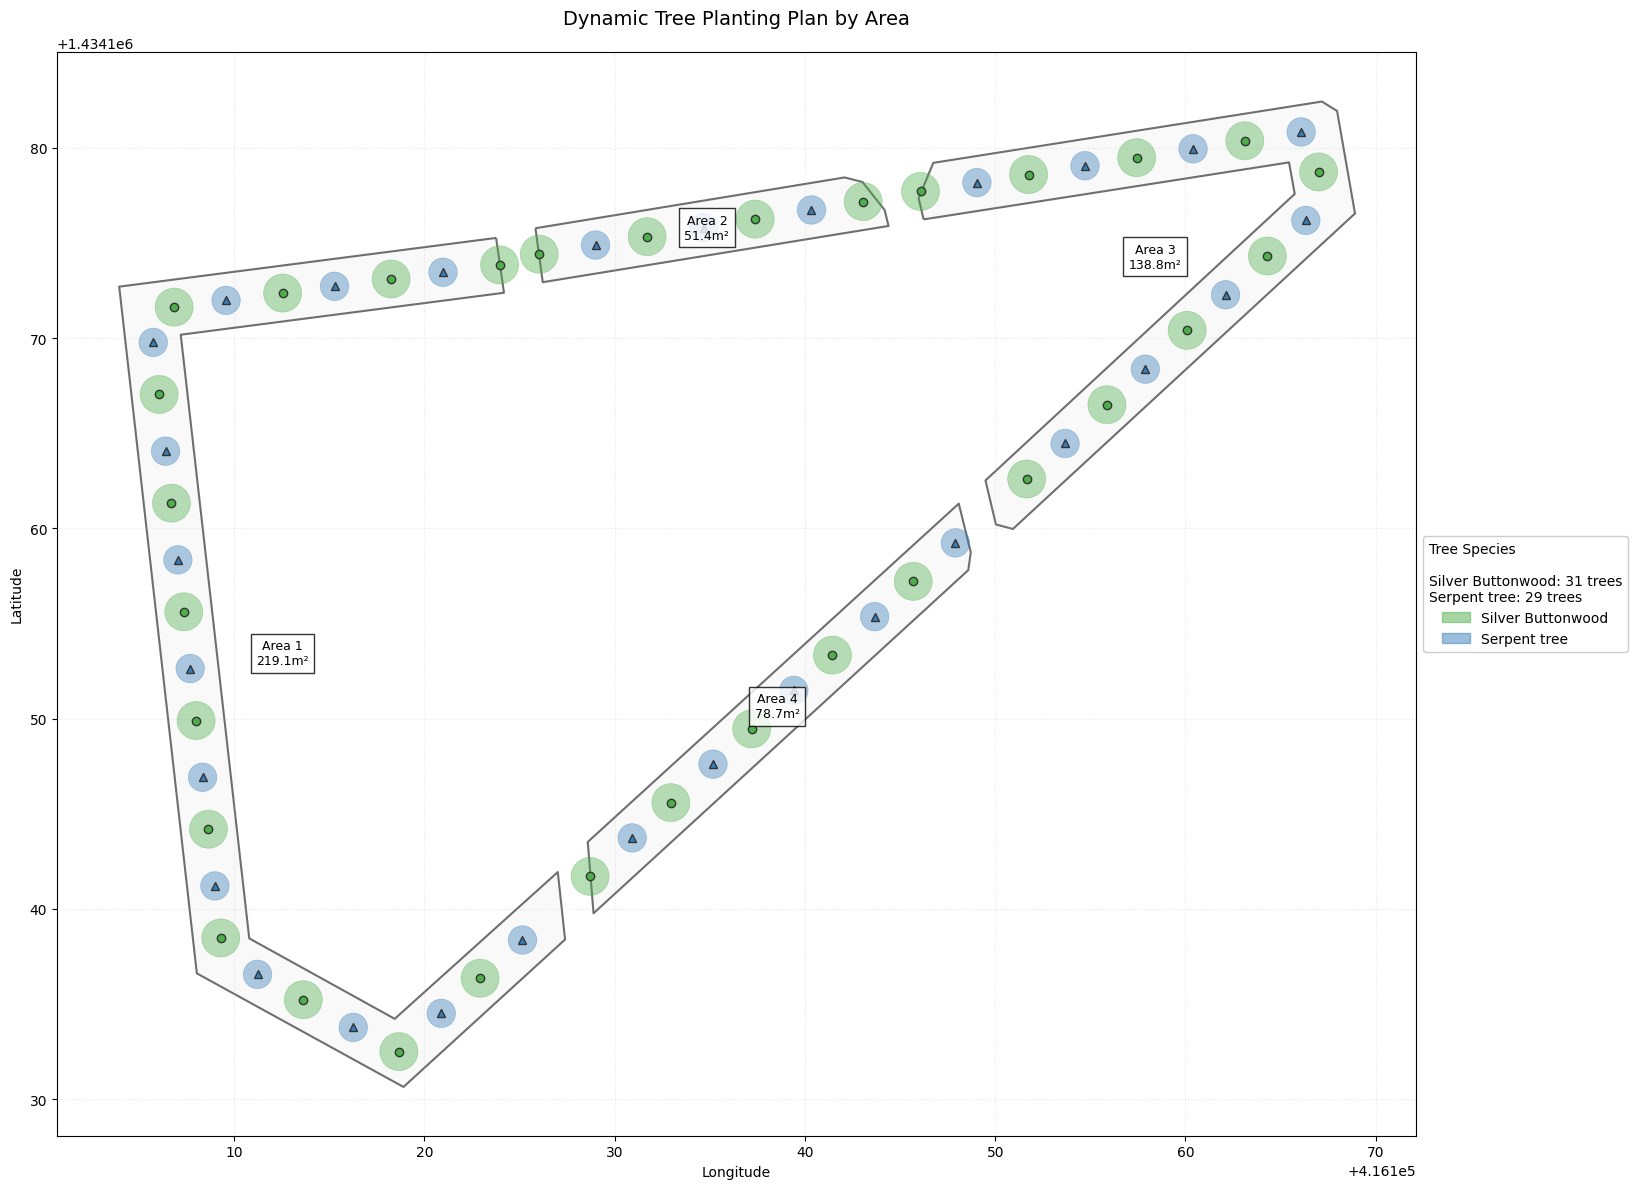

In [11]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from matplotlib.patches import Circle
import matplotlib.patches as mpatches

# Load all datasets
area_gdf = gpd.read_file("Community Park Area.geojson")
v_gdf = gpd.read_file("Community Park vertices.geojson")
l_gdf = gpd.read_file("Community Park lines.geojson")
recommendations_df = pd.read_csv("Current_Tree_Recommendations.csv")

# Get first two recommended trees for each area
def get_recommended_trees(df):
    tree_dict = {}
    for area_id in df['id'].unique():
        area_trees = df[df['id'] == area_id].head(2)
        tree_dict[area_id] = {
            1: {
                'name': area_trees.iloc[0]['Common Name'],
                'width': area_trees.iloc[0]['Max Width (m)'],
                'botanical': area_trees.iloc[0]['Botanical Name'],
                'score': area_trees.iloc[0]['Score (0-100)']
            },
            2: {
                'name': area_trees.iloc[1]['Common Name'],
                'width': area_trees.iloc[1]['Max Width (m)'],
                'botanical': area_trees.iloc[1]['Botanical Name'],
                'score': area_trees.iloc[1]['Score (0-100)']
            }
        }
    return tree_dict

# Assign colors and symbols based on tree types
def assign_tree_attributes(tree_dict):
    colors = ['#4daf4a', '#377eb8', '#984ea3', '#ff7f00', '#ffff33']
    symbols = ['o', '^', 's', 'D', 'p']

    all_names = []
    for area in tree_dict.values():
        for tree in area.values():
            if tree['name'] not in all_names:
                all_names.append(tree['name'])

    for area_id, trees in tree_dict.items():
        for i, (tree_id, tree) in enumerate(trees.items()):
            color_idx = all_names.index(tree['name']) % len(colors)
            symbol_idx = all_names.index(tree['name']) % len(symbols)
            tree_dict[area_id][tree_id]['color'] = colors[color_idx]
            tree_dict[area_id][tree_id]['symbol'] = symbols[symbol_idx]

    return tree_dict, all_names

# Process geometries and validate connections
def process_geometries(area_gdf, l_gdf):
    areas = {}
    for idx, row in area_gdf.iterrows():
        area_id = row['id']
        areas[area_id] = {
            'polygon': row.geometry,
            'properties': row.drop(['geometry']).to_dict()
        }

        # Find matching line
        line = l_gdf[l_gdf['id'] == area_id]
        if not line.empty:
            areas[area_id]['line'] = line.geometry.iloc[0]
        else:
            print(f"Warning: No line found for Area {area_id}")

    return areas

# Generate planting plan with dynamic spacing
def generate_planting_plan(area_data, tree_dict):
    planting_results = {}

    for area_id, data in area_data.items():
        if 'line' not in data:
            continue

        line = data['line']
        line_length = line.length
        planting_points = []
        counts = {1: 0, 2: 0}
        current_distance = 0

        # Get spacing based on area category
        category = data['properties'].get('Category', 'Shrub')

        # Define spacing rules for each category
        spacing_rules = {
            'Shrub': 2.0,
            'Small Tree': 4.0,
            'Medium Tree': 6.0,
            'Large Tree': 8.0,
            'Palm': 5.0
        }

        # Default to 4.0m if category is not found
        spacing = spacing_rules.get(category, 4.0)

        while current_distance < line_length:
            for tree_id in [1, 2]:
                if current_distance >= line_length:
                    break

                tree = tree_dict[area_id][tree_id]
                point = line.interpolate(current_distance)

                planting_points.append({
                    'x': point.x,
                    'y': point.y,
                    'tree_id': tree_id,
                    'width': tree['width'],
                    'name': tree['name']
                })

                counts[tree_id] += 1
                current_distance += tree['width']/2 + spacing

        planting_results[area_id] = {
            'points': planting_points,
            'counts': counts,
            'total': sum(counts.values()),
            'line_length': line_length,
            'spacing': spacing,
            'category': category  # Include category in results for verification
        }

    return planting_results

# Enhanced visualization with dynamic legend
def visualize_plan(area_data, planting_results, tree_dict, all_tree_names):
    fig, ax = plt.subplots(figsize=(16, 12))

    # Plot areas
    for area_id, data in area_data.items():
        gpd.GeoSeries([data['polygon']]).plot(
            ax=ax,
            facecolor='#f7f7f7',
            edgecolor='#333333',
            linewidth=1.5,
            alpha=0.7
        )

        # Area labels
        label = f"Area {area_id}\n{data['properties']['Area']:.1f}m²"
        ax.text(
            data['polygon'].centroid.x,
            data['polygon'].centroid.y,
            label,
            ha='center',
            va='center',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.8)
        )

    # Plot planting points
    color_map = {}
    symbol_map = {}
    for area_id, result in planting_results.items():
        for point in result['points']:
            tree_info = tree_dict[area_id][point['tree_id']]

            # Create consistent color mapping across all areas
            if tree_info['name'] not in color_map:
                color_map[tree_info['name']] = tree_info['color']
                symbol_map[tree_info['name']] = tree_info['symbol']

            # Tree canopy
            ax.add_patch(Circle(
                (point['x'], point['y']),
                point['width']/2,
                color=tree_info['color'],
                alpha=0.4,
                ec=tree_info['color'],
                lw=0.5
            ))

            # Tree center
            ax.plot(
                point['x'], point['y'],
                tree_info['symbol'],
                color=tree_info['color'],
                markersize=6,
                markeredgecolor='#333333'
            )

    # Create dynamic legend
    legend_elements = []
    for name in all_tree_names:
        if name in color_map:
            legend_elements.append(
                mpatches.Patch(
                    color=color_map[name],
                    label=f"{name}",
                    alpha=0.5
                )
            )

    # Add statistics
    total_counts = {}
    for area_id, result in planting_results.items():
        for tree_id, count in result['counts'].items():
            name = tree_dict[area_id][tree_id]['name']
            total_counts[name] = total_counts.get(name, 0) + count

    legend_title = "Tree Species\n"
    for name, count in total_counts.items():
        legend_title += f"\n{name}: {count} trees"

    plt.legend(
        handles=legend_elements,
        title=legend_title,
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        framealpha=1
    )

    plt.title("Dynamic Tree Planting Plan by Area", fontsize=14, pad=20)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.savefig('Dynamic_Tree_Planting_Plan.png', dpi=300, bbox_inches='tight')
    plt.show()

# Main execution
def main():
    # Process recommended trees
    tree_dict = get_recommended_trees(recommendations_df)
    tree_dict, all_tree_names = assign_tree_attributes(tree_dict)

    # Process geometries
    area_data = process_geometries(area_gdf, l_gdf)

    # Generate planting plan
    planting_results = generate_planting_plan(area_data, tree_dict)

    # Print summary
    print("PLANTING PLAN SUMMARY:")
    for area_id, result in planting_results.items():
        tree1 = tree_dict[area_id][1]['name']
        tree2 = tree_dict[area_id][2]['name']
        print(
            f"\nArea {area_id}:"
            f"\n- {tree1}: {result['counts'][1]} trees"
            f"\n- {tree2}: {result['counts'][2]} trees"
            f"\n- Total: {result['total']} trees"
            f"\n- Line length: {result['line_length']:.1f}m"
            f"\n- Spacing: {result['spacing']}m"
        )

    # Visualize
    visualize_plan(area_data, planting_results, tree_dict, all_tree_names)

if __name__ == "__main__":
    main()